# Model 03: XGBoost with Hyperparameter Tuning

Gradient boosting with Optuna hyperparameter optimization.

In [7]:
pip install optuna


  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached sqlalchemy-2.0.49-cp312-cp312-win_amd64.whl.metadata (9.8 kB)
  Using cached greenlet-3.3.2-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
Using cached optuna-4.8.0-py3-none-any.whl (419 kB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
Using cached sqlalchemy-2.0.49-cp312-cp312-win_amd64.whl (2.1 MB)
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
Using cached greenlet-3.3.2-cp312-cp312-win_amd64.whl (231 kB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\Python312\\Include\\greenlet'
Consider using the `--user` option or check the permissions.



In [8]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '..')

from src.models.xgboost_model import XGBoostModel, XGBoostTuner
from src.evaluation.metrics import MetricsCalculator, train_test_split_by_date
from src.features.builders import FeatureBuilder

# Load data
df = pd.read_csv('../data/processed/features_full.csv', parse_dates=['date'])

# Build features
builder = FeatureBuilder()
feature_cols = builder.get_feature_columns(df, target_col='new_cases')

# Drop NAs
df_clean = df.dropna(subset=feature_cols + ['new_cases'])

# Split
train_df, val_df, test_df = train_test_split_by_date(df_clean, test_size=0.15, val_size=0.1)

# Prepare data
X_train = train_df[feature_cols].values
y_train = train_df['new_cases'].values
X_val = val_df[feature_cols].values
y_val = val_df['new_cases'].values
X_test = test_df[feature_cols].values
y_test = test_df['new_cases'].values

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 873, Val: 98, Test: 172


## Hyperparameter Tuning with Optuna

In [10]:
# Tune hyperparameters
tuner = XGBoostTuner(n_trials=30, timeout=300)
best_params = tuner.tune(X_train, y_train, X_val, y_val, feature_names=feature_cols)

# Check if tuning succeeded
if best_params is not None:
    print(f"\n✓ Tuning complete! Best params: {best_params}")
    model = tuner.create_best_model()
else:
    print("\n⚠ Tuning failed or incomplete. Using default XGBoost parameters.")
    model = XGBoostModel(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

# Train on train+val
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

model.fit(X_train_full, y_train_full, feature_names=feature_cols)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("\nTest Set Performance:")
MetricsCalculator.print_metrics(y_test, y_pred)

Optuna not installed. Install with: pip install optuna



⚠ Tuning failed or incomplete. Using default XGBoost parameters.
[0]	train-rmse:40760.32080
[50]	train-rmse:507.00919
[100]	train-rmse:172.52847
[150]	train-rmse:89.71907
[199]	train-rmse:53.08460

Test Set Performance:

Metrics:
----------------------------------------
  MAE     : 342.2729
  RMSE    : 444.2684
  MAPE    : 137.1218
  MDA     : 84.2105
  R2      : 0.8902


{'mae': np.float64(342.27288263620335),
 'rmse': np.float64(444.2683865334471),
 'mape': np.float64(137.12176991290792),
 'mda': np.float64(84.21052631578947),
 'r2': 0.8901521656898304}

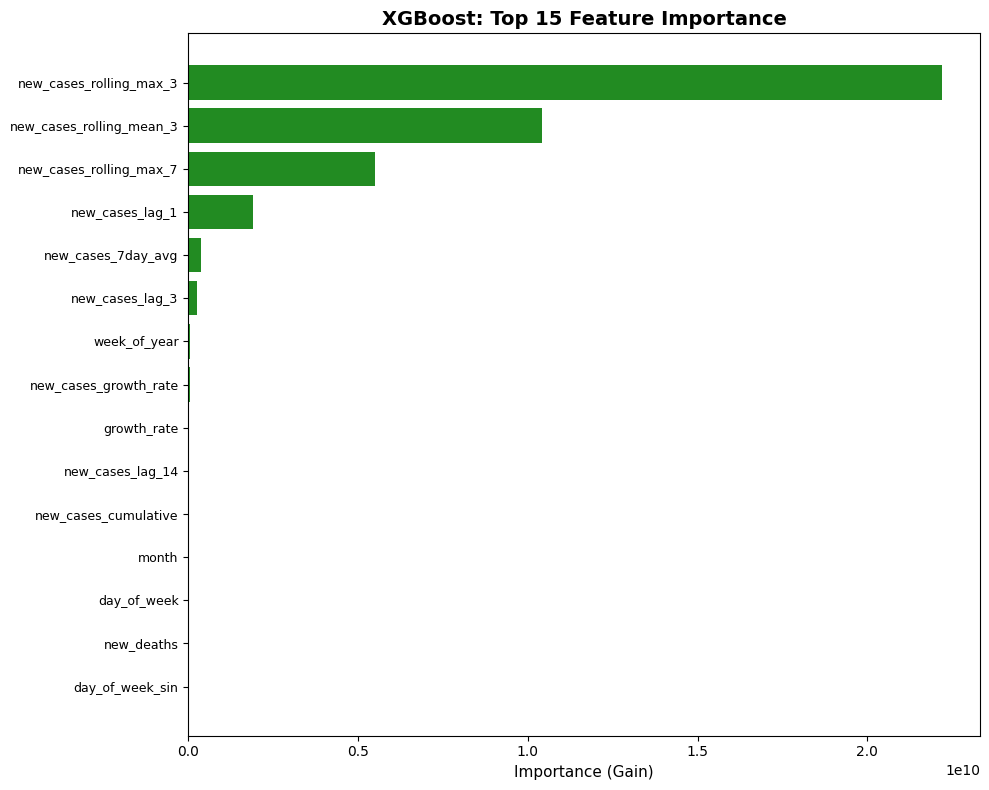


✓ Model saved


In [11]:
# Feature importance
importance = model.get_feature_importance()

fig, ax = plt.subplots(figsize=(10, 8))
top_15 = importance.head(15)
ax.barh(range(len(top_15)), top_15['importance'], color='forestgreen')
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['feature'], fontsize=9)
ax.set_xlabel('Importance (Gain)', fontsize=11)
ax.set_title('XGBoost: Top 15 Feature Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/06_xgboost_importance.png', dpi=300)
plt.show()

# Save
model.save('../models/xgboost_model.json')
print("\n✓ Model saved")